In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import v2


In [3]:
import kagglehub
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")
print("Path to dataset files:", path)

ModuleNotFoundError: No module named 'kagglehub'

In [ ]:
with Image.open(path + "/Training/glioma/Tr-gl_10.jpg") as im:
    print(im.width, im.height)

512 512


In [ ]:
TRAINING_DIR = Path(path + '/Training')
TESTING_DIR = Path(path + '/Testing')

# ImageNet mean/std for pretrained model normalisation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.RandomHorizontalFlip(),
    v2.RandomRotation(15),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(root=TRAINING_DIR, transform=train_transform)
test_dataset  = datasets.ImageFolder(root=TESTING_DIR,  transform=test_transform)

print(f"Classes: {train_dataset.classes}")
print(f"Training samples: {len(train_dataset)}")
print(f"Testing samples:  {len(test_dataset)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Training samples: 5600
Testing samples:  1600


In [4]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Verify a batch
images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape}")   # (32, 3, 512, 512)
print(f"Batch label shape: {labels.shape}")   # (32,)
print(f"Label mapping: {train_dataset.class_to_idx}")

Train batches: 175
Test batches:  50
Batch image shape: torch.Size([32, 3, 224, 224])
Batch label shape: torch.Size([32])
Label mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet50 and replace the final classification head
model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, 4)
model = model.to(device)

print(f"Total parameters:     {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cuda


1.3%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/jeremy/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


Total parameters:     23,516,228
Trainable parameters: 23,516,228


In [6]:
EPOCHS = 20
LR = 1e-3
CHECKPOINT = Path("best_model.pth")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_acc = 0.0

for epoch in range(EPOCHS):
    # --- Training ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    train_loss = running_loss / total
    train_acc  = correct / total

    # --- Evaluation ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    test_loss = running_loss / total
    test_acc  = correct / total

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    # --- Save best checkpoint ---
    saved = ""
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), CHECKPOINT)
        saved = "  *** saved ***"

    print(f"Epoch {epoch+1:02d}/{EPOCHS}  "
          f"train loss: {train_loss:.4f}  train acc: {train_acc:.4f}  "
          f"test loss: {test_loss:.4f}  test acc: {test_acc:.4f}{saved}")

print(f"\nBest test accuracy: {best_acc:.4f}  →  saved to '{CHECKPOINT}'")

Epoch 01/20  train loss: 0.3562  train acc: 0.8811  test loss: 0.6890  test acc: 0.8344  *** saved ***
Epoch 02/20  train loss: 0.1776  train acc: 0.9373  test loss: 0.4966  test acc: 0.8744  *** saved ***
Epoch 03/20  train loss: 0.1523  train acc: 0.9491  test loss: 0.6361  test acc: 0.8400
Epoch 04/20  train loss: 0.1086  train acc: 0.9637  test loss: 0.4666  test acc: 0.9294  *** saved ***
Epoch 05/20  train loss: 0.1041  train acc: 0.9630  test loss: 0.5730  test acc: 0.9187
Epoch 06/20  train loss: 0.0926  train acc: 0.9689  test loss: 0.6608  test acc: 0.8894
Epoch 07/20  train loss: 0.0783  train acc: 0.9745  test loss: 0.5757  test acc: 0.8975
Epoch 08/20  train loss: 0.0408  train acc: 0.9871  test loss: 0.3830  test acc: 0.9537  *** saved ***
Epoch 09/20  train loss: 0.0236  train acc: 0.9945  test loss: 0.4379  test acc: 0.9519
Epoch 10/20  train loss: 0.0172  train acc: 0.9957  test loss: 0.4142  test acc: 0.9550  *** saved ***
Epoch 11/20  train loss: 0.0113  train acc: 0

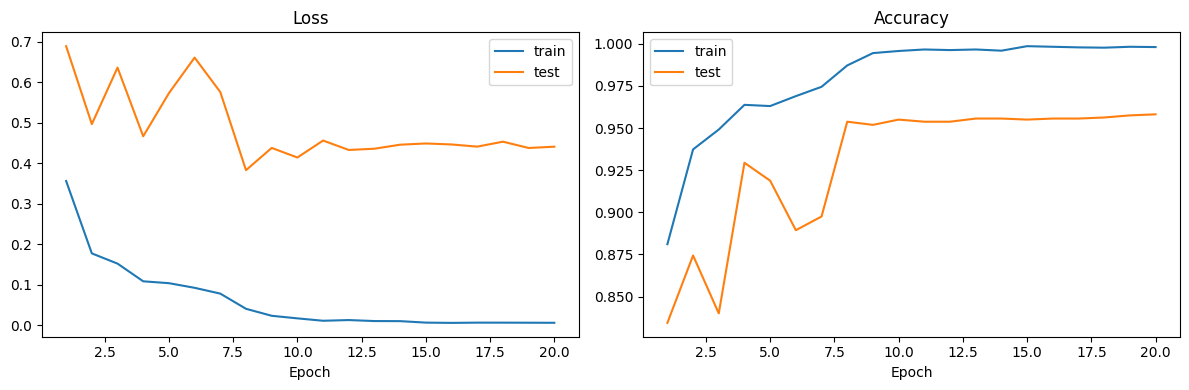

Best test accuracy: 0.9581


In [7]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history["train_loss"], label="train")
ax1.plot(epochs, history["test_loss"],  label="test")
ax1.set_title("Loss"); ax1.set_xlabel("Epoch"); ax1.legend()

ax2.plot(epochs, history["train_acc"], label="train")
ax2.plot(epochs, history["test_acc"],  label="test")
ax2.set_title("Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()

plt.tight_layout()
plt.show()

print(f"Best test accuracy: {max(history['test_acc']):.4f}")

In [1]:
# Load best checkpoint for downstream explainability / calibration analyses
model.load_state_dict(torch.load(CHECKPOINT, map_location=device))
model.eval()
print(f"Loaded best checkpoint from: {CHECKPOINT}")


NameError: name 'model' is not defined

In [ ]:
# ------------------------------
# 1) Grad-CAM + occlusion faithfulness check
# ------------------------------

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=tensor.device).view(1, 3, 1, 1)
    return tensor * std + mean


def compute_gradcam(input_tensor, model, target_layer, class_idx=None):
    activations = []
    gradients = []

    def forward_hook(_, __, output):
        activations.append(output.detach())

    def backward_hook(_, grad_input, grad_output):
        gradients.append(grad_output[0].detach())

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(input_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, class_idx].backward(retain_graph=True)

    acts = activations[0]
    grads = gradients[0]
    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode='bilinear', align_corners=False)

    cam = cam[0, 0]
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    fh.remove()
    bh.remove()
    return cam, output.detach(), class_idx


def top_region_bbox(cam, top_fraction=0.15):
    h, w = cam.shape
    flat = cam.flatten()
    k = max(1, int(top_fraction * flat.numel()))
    values, _ = torch.topk(flat, k)
    threshold = values[-1]
    mask = cam >= threshold

    ys, xs = torch.where(mask)
    y0, y1 = ys.min().item(), ys.max().item()
    x0, x1 = xs.min().item(), xs.max().item()
    return (x0, y0, x1, y1), mask


def mask_bbox(input_tensor, bbox, fill=0.0):
    x0, y0, x1, y1 = bbox
    masked = input_tensor.clone()
    masked[:, :, y0:y1 + 1, x0:x1 + 1] = fill
    return masked


def random_bbox_like(bbox, h, w):
    x0, y0, x1, y1 = bbox
    bw = x1 - x0 + 1
    bh = y1 - y0 + 1
    rx0 = random.randint(0, max(0, w - bw))
    ry0 = random.randint(0, max(0, h - bh))
    return (rx0, ry0, rx0 + bw - 1, ry0 + bh - 1)


def confidence_for_class(logits, class_idx):
    probs = F.softmax(logits, dim=1)
    return probs[0, class_idx].item()


# Run faithfulness check on a few random test cases
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

n_cases = 8
indices = np.random.choice(len(test_dataset), size=min(n_cases, len(test_dataset)), replace=False)
rows = []

for idx in indices:
    image, label = test_dataset[idx]
    input_tensor = image.unsqueeze(0).to(device)

    cam, logits, pred_idx = compute_gradcam(input_tensor, model, model.layer4[-1], class_idx=None)
    base_conf = confidence_for_class(logits, pred_idx)

    bbox, cam_mask = top_region_bbox(cam, top_fraction=0.15)
    rand_bbox = random_bbox_like(bbox, cam.shape[0], cam.shape[1])

    logits_top = model(mask_bbox(input_tensor, bbox))
    logits_rand = model(mask_bbox(input_tensor, rand_bbox))

    conf_top = confidence_for_class(logits_top, pred_idx)
    conf_rand = confidence_for_class(logits_rand, pred_idx)

    rows.append({
        'idx': int(idx),
        'pred': train_dataset.classes[pred_idx],
        'true': train_dataset.classes[label],
        'base_conf': base_conf,
        'drop_top': base_conf - conf_top,
        'drop_rand': base_conf - conf_rand,
        'cam': cam.detach().cpu(),
        'image': input_tensor.detach().cpu(),
        'bbox': bbox,
        'rand_bbox': rand_bbox,
    })

mean_drop_top = float(np.mean([r['drop_top'] for r in rows]))
mean_drop_rand = float(np.mean([r['drop_rand'] for r in rows]))

print('Faithfulness check (confidence drop on predicted class):')
print(f"Mean drop when masking top Grad-CAM region: {mean_drop_top:.4f}")
print(f"Mean drop when masking random region:       {mean_drop_rand:.4f}")
print('Per-case:')
for r in rows:
    print(
        f"idx={r['idx']:4d} pred={r['pred']:<10} true={r['true']:<10} "
        f"drop_top={r['drop_top']:.4f} drop_rand={r['drop_rand']:.4f}"
    )

# Plot comparison bars
plt.figure(figsize=(6, 4))
plt.bar(['Top Grad-CAM region', 'Random region'], [mean_drop_top, mean_drop_rand], color=['#d62728', '#1f77b4'])
plt.ylabel('Mean confidence drop')
plt.title('Occlusion faithfulness test')
plt.tight_layout()
plt.show()

# Visualize one example heatmap overlay
example = rows[0]
img_denorm = denormalize(example['image']).squeeze(0).permute(1, 2, 0).numpy()
img_denorm = np.clip(img_denorm, 0, 1)
cam_np = example['cam'].numpy()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(img_denorm)
plt.title(f"Original | pred={example['pred']}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_denorm)
plt.imshow(cam_np, cmap='jet', alpha=0.45)
plt.title('Grad-CAM overlay')
plt.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
# ------------------------------
# 2) Uncertainty + calibration (ECE, reliability, temperature scaling)
# ------------------------------

def collect_logits(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x).cpu()
            all_logits.append(logits)
            all_labels.append(y)
    return torch.cat(all_logits), torch.cat(all_labels)


def expected_calibration_error(probs, labels, n_bins=10):
    confidences, predictions = probs.max(dim=1)
    accuracies = predictions.eq(labels)

    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    ece = torch.zeros(1)
    bin_stats = []

    for i in range(n_bins):
        lower, upper = bin_boundaries[i], bin_boundaries[i + 1]
        in_bin = (confidences > lower) & (confidences <= upper)
        prop_in_bin = in_bin.float().mean()

        if in_bin.any():
            acc_in_bin = accuracies[in_bin].float().mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += torch.abs(conf_in_bin - acc_in_bin) * prop_in_bin
            bin_stats.append((float(conf_in_bin), float(acc_in_bin), int(in_bin.sum())))
        else:
            bin_stats.append((0.0, 0.0, 0))

    return float(ece.item()), bin_stats


class ModelWithTemperature(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.temperature = nn.Parameter(torch.ones(1) * 1.0)

    def forward(self, x):
        logits = self.model(x)
        return self.temperature_scale(logits)

    def temperature_scale(self, logits):
        temperature = self.temperature.to(logits.device)
        t = temperature.unsqueeze(1).expand(logits.size(0), logits.size(1))
        return logits / t


def fit_temperature(logits, labels):
    logits_dev = logits.to(device)
    labels_dev = labels.to(device)
    temp_model = ModelWithTemperature(model).to(logits_dev.device)
    temp_model.temperature.data = torch.ones(1, device=logits_dev.device) * 1.0

    nll_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([temp_model.temperature], lr=0.01, max_iter=50)


    def _eval():
        optimizer.zero_grad()
        loss = nll_criterion(temp_model.temperature_scale(logits_dev), labels_dev)
        loss.backward()
        return loss

    optimizer.step(_eval)
    return float(temp_model.temperature.item())


logits, labels = collect_logits(model, test_loader, device)
probs = F.softmax(logits, dim=1)
ece_before, bins_before = expected_calibration_error(probs, labels, n_bins=10)

temperature = fit_temperature(logits, labels)
probs_temp = F.softmax(logits / temperature, dim=1)
ece_after, bins_after = expected_calibration_error(probs_temp, labels, n_bins=10)

print(f"ECE before temperature scaling: {ece_before:.4f}")
print(f"ECE after temperature scaling:  {ece_after:.4f}")
print(f"Fitted temperature:             {temperature:.3f}")

# Reliability diagram (before/after)
centers = np.linspace(0.05, 0.95, 10)
conf_before = [b[0] for b in bins_before]
acc_before = [b[1] for b in bins_before]
conf_after = [b[0] for b in bins_after]
acc_after = [b[1] for b in bins_after]

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, conf, acc, title in [
    (axes[0], conf_before, acc_before, 'Before calibration'),
    (axes[1], conf_after, acc_after, 'After temperature scaling'),
]:
    ax.plot([0, 1], [0, 1], '--', color='gray')
    ax.bar(centers, acc, width=0.09, alpha=0.6, label='Accuracy')
    ax.plot(centers, conf, color='red', marker='o', label='Confidence')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel('Confidence bin')
    ax.set_title(title)
axes[0].set_ylabel('Accuracy')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

# Clinician-facing uncertainty message example
sample_idx = 0
sample_img, _ = test_dataset[sample_idx]
sample_logits = model(sample_img.unsqueeze(0).to(device)).detach().cpu()
sample_probs = F.softmax(sample_logits / temperature, dim=1)[0]
conf, pred = torch.max(sample_probs, dim=0)
label_name = train_dataset.classes[pred.item()]

print(f"Example prediction: {label_name} with calibrated confidence {conf.item():.2f}")
if conf.item() < 0.70:
    print('Interpretation: uncertain prediction; suggest specialist review.')
else:
    print('Interpretation: relatively confident prediction.')


In [ ]:
# ------------------------------
# 3) Case-based explanations with nearest-neighbor retrieval
# ------------------------------

embedding_transform = v2.Compose([
    v2.Resize((224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_embed_dataset = datasets.ImageFolder(root=TRAINING_DIR, transform=embedding_transform)
train_embed_loader = DataLoader(train_embed_dataset, batch_size=BATCH_SIZE, shuffle=False)


def extract_resnet_embedding(model, x):
    x = model.conv1(x)
    x = model.bn1(x)
    x = model.relu(x)
    x = model.maxpool(x)
    x = model.layer1(x)
    x = model.layer2(x)
    x = model.layer3(x)
    x = model.layer4(x)
    x = model.avgpool(x)
    x = torch.flatten(x, 1)
    return x


def build_embedding_bank(model, loader, device):
    model.eval()
    embs, labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            z = extract_resnet_embedding(model, x)
            z = F.normalize(z, p=2, dim=1)
            embs.append(z.cpu())
            labels.append(y)
    return torch.cat(embs), torch.cat(labels)


train_embs, train_labels = build_embedding_bank(model, train_embed_loader, device)
train_paths = [s[0] for s in train_embed_dataset.samples]


def retrieve_neighbors(query_img, k=3):
    model.eval()
    with torch.no_grad():
        q = extract_resnet_embedding(model, query_img.unsqueeze(0).to(device))
        q = F.normalize(q, p=2, dim=1).cpu()
        sims = torch.mm(q, train_embs.t()).squeeze(0)
        vals, idxs = torch.topk(sims, k=min(k, len(train_embs)))
    return vals.numpy(), idxs.numpy()


# Demonstrate for one test image
query_idx = 0
query_img, query_label = test_dataset[query_idx]
query_logits = model(query_img.unsqueeze(0).to(device)).detach().cpu()
query_probs = F.softmax(query_logits / temperature, dim=1)[0]
query_pred = int(torch.argmax(query_probs))

scores, nbr_idxs = retrieve_neighbors(query_img, k=3)

print(f"Query prediction: {train_dataset.classes[query_pred]} (confidence={query_probs[query_pred]:.2f})")
print('Nearest training examples (cosine similarity):')
for rank, (score, ni) in enumerate(zip(scores, nbr_idxs), start=1):
    cls = train_embed_dataset.classes[train_labels[ni].item()]
    print(f"{rank}. class={cls:<10} sim={score:.4f} path={train_paths[ni]}")

# Visual panel: query + nearest neighbors
fig, axes = plt.subplots(1, len(nbr_idxs) + 1, figsize=(3 * (len(nbr_idxs) + 1), 3))

query_vis = denormalize(query_img.unsqueeze(0)).squeeze(0).permute(1, 2, 0).numpy()
axes[0].imshow(np.clip(query_vis, 0, 1))
axes[0].set_title(f"Query true={train_dataset.classes[query_label]} pred={train_dataset.classes[query_pred]}")
axes[0].axis('off')

for j, ni in enumerate(nbr_idxs, start=1):
    with Image.open(train_paths[ni]) as im:
        nbr_np = np.array(im.convert('RGB').resize((224, 224))) / 255.0
    cls = train_embed_dataset.classes[train_labels[ni].item()]
    axes[j].imshow(nbr_np)
    axes[j].set_title(f"NN{j} {cls} sim={scores[j-1]:.2f}")
    axes[j].axis('off')

plt.tight_layout()
plt.show()
